# Эксперементы с Leaf Model

## Датасет №1

In [1]:
import kagglehub
import pandas as pd
import os

path1 = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")
file_path = os.path.join(path1, 'E Commerce Dataset.xlsx')
df = pd.read_excel(file_path, sheet_name='E Comm', usecols='A:T')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### Предобработка

In [2]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin

class ValueReplacer(BaseEstimator, TransformerMixin):
    def __init__(self, replacements: dict):
        self.replacements = replacements

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, mapping in self.replacements.items():
            if col in X.columns:
                X[col] = X[col].replace(mapping)
        return X
    
    def get_feature_names_out(self, input_features=None):
        return input_features

def create_preprocessing_pipeline(X, encoder: str = 'onehot', scale: bool = True):
    cat_columns = X.select_dtypes(include=['object', 'string']).columns.tolist()
    num_columns = X.select_dtypes(include='number').columns.tolist()
    
    for col in ['Churn', 'CustomerID']:
        if col in cat_columns: cat_columns.remove(col)
        if col in num_columns: num_columns.remove(col)

    replacements = {
        'PreferredLoginDevice': {'Mobile Phone': 'Phone'},
        'PreferredPaymentMode': {'Credit Card': 'CC'},
        'PreferedOrderCat': {'Mobile Phone': 'Mobile'}
    }

    num_steps = [('imputer', SimpleImputer(strategy='mean'))]
    if scale:
        num_steps.append(('scaler', StandardScaler()))
    num_pipe = Pipeline(num_steps)

    cat_steps = [('imputer', SimpleImputer(strategy='most_frequent'))]
    if encoder == 'onehot':
        cat_steps.append(('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)))
    elif encoder == 'ordinal':
        cat_steps.append(('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)))
    else:
        raise ValueError("encoder должен быть 'onehot' или 'ordinal'")
    cat_pipe = Pipeline(cat_steps)

    # 🔑 FIX: verbose_feature_names_out=False убирает префиксы num__ и cat__
    preprocessor = ColumnTransformer([
        ('num', num_pipe, num_columns),
        ('cat', cat_pipe, cat_columns)
    ], remainder='drop', verbose_feature_names_out=False)

    pipeline = Pipeline([
        ('replacer', ValueReplacer(replacements)),
        ('preprocessor', preprocessor)
    ])

    # ✅ Автоматический вывод в DataFrame с корректными именами
    pipeline.set_output(transform="pandas")
    return pipeline

In [3]:
from sklearn.model_selection import train_test_split

# 1. Разделяем данные
X = df.drop(columns=['Churn', 'CustomerID'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Создаём пайплайн
pipe_sc = create_preprocessing_pipeline(X_train, encoder='onehot', scale=True)
X_train_sc = pipe_sc.fit_transform(X_train)
X_test_sc  = pipe_sc.transform(X_test)

pipe_ohe = create_preprocessing_pipeline(X_train, encoder='onehot', scale=False)
X_train_ohe = pipe_ohe.fit_transform(X_train)
X_test_ohe  = pipe_ohe.transform(X_test)

pipe_ord = create_preprocessing_pipeline(X_train, encoder='ordinal', scale=False)
X_train_ord = pipe_ord.fit_transform(X_train)
X_test_ord = pipe_ord.transform(X_test)

### Эксперименты

In [4]:
from scripts.leaf_model import LeafModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [5]:
from sklearn.linear_model import LogisticRegression

base_tree = DecisionTreeClassifier(max_leaf_nodes=5, random_state=42)
model_lr = LeafModel(tree=base_tree, leaf_model=LogisticRegression(max_iter=1000, random_state=42))

grid = GridSearchCV(model_lr, param_grid={'leaf_model__C': [0.1, 1.0, 10.0]}, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_sc, y_train)

y_pred = grid.predict(X_test_sc)
y_prob = grid.predict_proba(X_test_sc)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'leaf_model__C': 10.0}
Acc: 0.9094 | Prec: 0.8188 | Rec: 0.5947 | F1: 0.6890 | ROC-AUC: 0.9077
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       936
           1       0.82      0.59      0.69       190

    accuracy                           0.91      1126
   macro avg       0.87      0.78      0.82      1126
weighted avg       0.90      0.91      0.90      1126



In [6]:
from sklearn.ensemble import RandomForestClassifier

model_rf = LeafModel(tree=base_tree, leaf_model=RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1))

grid = GridSearchCV(model_rf, param_grid={'leaf_model__max_depth': [3, 5, None], 'leaf_model__min_samples_split': [2, 5]}, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train_ord, y_train)

y_pred = grid.predict(X_test_ord)
y_prob = grid.predict_proba(X_test_ord)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'leaf_model__max_depth': None, 'leaf_model__min_samples_split': 5}
Acc: 0.9813 | Prec: 0.9721 | Rec: 0.9158 | F1: 0.9431 | ROC-AUC: 0.9965
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       936
           1       0.97      0.92      0.94       190

    accuracy                           0.98      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126



In [7]:
best_model = grid.best_estimator_
info_df = best_model.get_leaf_info(as_dataframe=True)
info_df[['leaf_id', 'rule', 'n_samples']]

,leaf_id,rule,n_samples
7,7,0 <= 1.5000 AND 7 <= 0.5000 AND 6 <= 5.5000,494
8,8,0 <= 1.5000 AND 7 <= 0.5000 AND 6 > 5.5000,127
4,4,0 <= 1.5000 AND 7 > 0.5000,353
5,5,0 > 1.5000 AND 12 <= 123.6450,244
6,6,0 > 1.5000 AND 12 > 123.6450,3286


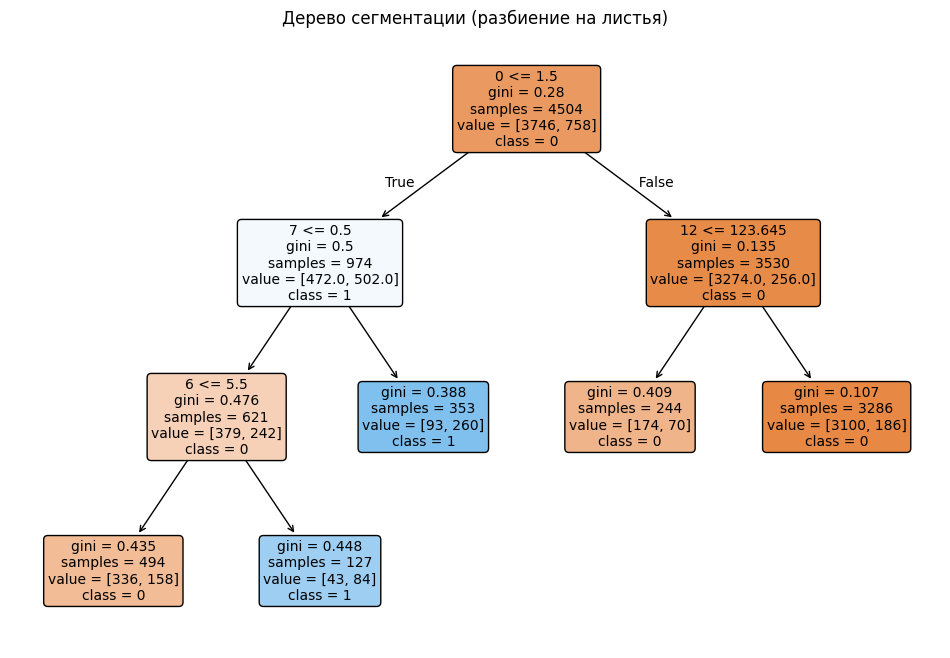

|--- 0 <= 1.50
|   |--- 7 <= 0.50
|   |   |--- 6 <= 5.50
|   |   |   |--- class: 0
|   |   |--- 6 >  5.50
|   |   |   |--- class: 1
|   |--- 7 >  0.50
|   |   |--- class: 1
|--- 0 >  1.50
|   |--- 12 <= 123.65
|   |   |--- class: 0
|   |--- 12 >  123.65
|   |   |--- class: 0



In [8]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# Графическое представление
plt.figure(figsize=(12, 8))
plot_tree(best_model.tree_, 
          feature_names=best_model.feature_names_in_, 
          class_names=best_model.classes_.astype(str), 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Дерево сегментации (разбиение на листья)")
plt.show()

# Текстовое представление правил (удобно для отладки)
print(export_text(best_model.tree_, feature_names=list(best_model.feature_names_in_)))

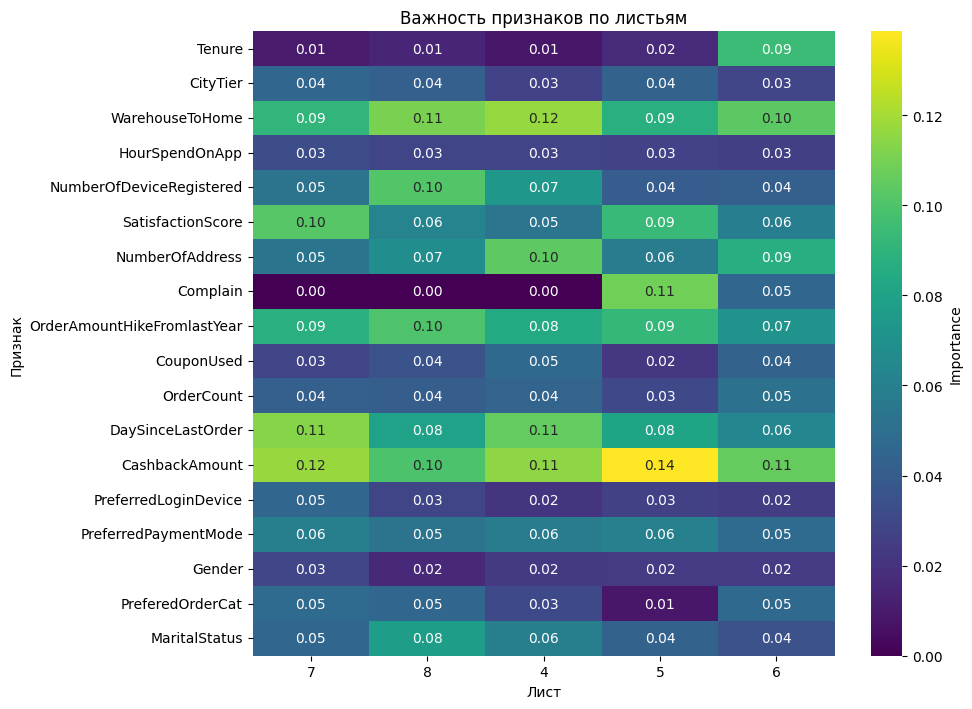

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_imp = pd.DataFrame(leaf_imps).fillna(0)  # листья — колонки, признаки — строки

plt.figure(figsize=(10, max(4, len(df_imp) * 0.4)))
sns.heatmap(df_imp, cmap='viridis', annot=True, fmt='.2f', cbar_kws={'label': 'Importance'})
plt.title('Важность признаков по листьям')
plt.xlabel('Лист')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = LeafModel(leaf_model=GradientBoostingClassifier(random_state=42))

grid = GridSearchCV(model_gb, param_grid={
    'leaf_model__n_estimators': [50, 100, 150], 
    'leaf_model__max_depth': [3, 5, 7], 
    'leaf_model__learning_rate': [0.01, 0.1, 0.2]
}, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train_ord, y_train)

y_pred = grid.predict(X_test_ord)
y_prob = grid.predict_proba(X_test_ord)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'leaf_model__learning_rate': 0.2, 'leaf_model__max_depth': 5, 'leaf_model__n_estimators': 150}
Acc: 0.9885 | Prec: 0.9784 | Rec: 0.9526 | F1: 0.9653 | ROC-AUC: 0.9989
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       936
           1       0.98      0.95      0.97       190

    accuracy                           0.99      1126
   macro avg       0.98      0.97      0.98      1126
weighted avg       0.99      0.99      0.99      1126



In [ ]:
best_model = grid.best_estimator_
info_df = best_model.get_leaf_info(as_dataframe=True)
info_df[['leaf_id', 'rule', 'n_samples']]

,leaf_id,rule,n_samples
7,7,Tenure <= 1.5000 AND Complain <= 0.5000 AND Nu...,494
8,8,Tenure <= 1.5000 AND Complain <= 0.5000 AND Nu...,127
4,4,Tenure <= 1.5000 AND Complain > 0.5000,353
5,5,Tenure > 1.5000 AND CashbackAmount <= 123.6450,244
6,6,Tenure > 1.5000 AND CashbackAmount > 123.6450,3286


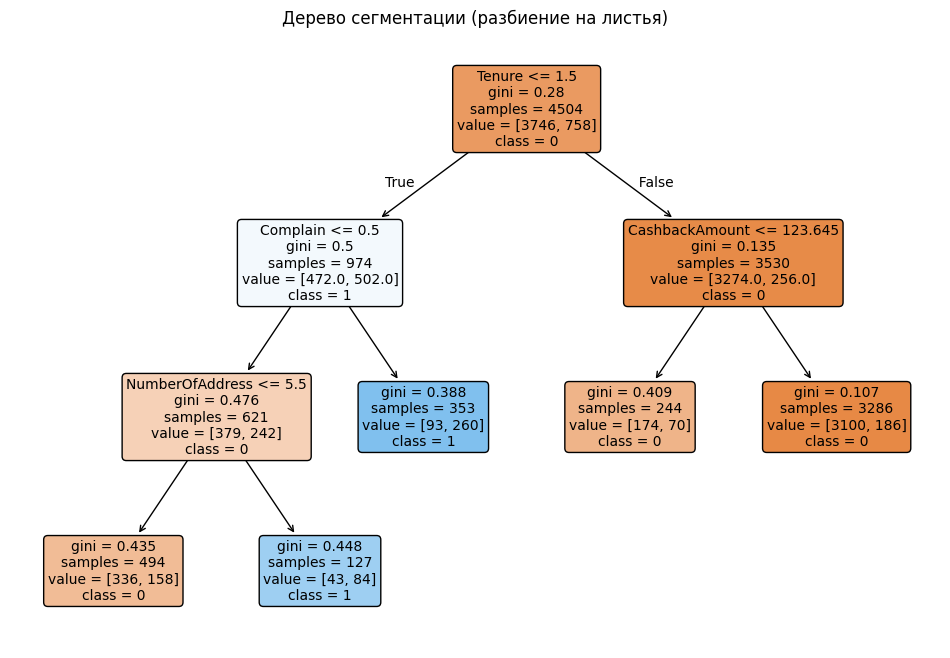

|--- Tenure <= 1.50
|   |--- Complain <= 0.50
|   |   |--- NumberOfAddress <= 5.50
|   |   |   |--- class: 0
|   |   |--- NumberOfAddress >  5.50
|   |   |   |--- class: 1
|   |--- Complain >  0.50
|   |   |--- class: 1
|--- Tenure >  1.50
|   |--- CashbackAmount <= 123.65
|   |   |--- class: 0
|   |--- CashbackAmount >  123.65
|   |   |--- class: 0



In [ ]:
# Графическое представление
plt.figure(figsize=(12, 8))
plot_tree(best_model.tree_, 
          feature_names=best_model.feature_names_in_, 
          class_names=best_model.classes_.astype(str), 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Дерево сегментации (разбиение на листья)")
plt.show()

# Текстовое представление правил (удобно для отладки)
print(export_text(best_model.tree_, feature_names=list(best_model.feature_names_in_)))

In [ ]:
leaf_imps = {}
for _, row in best_model.get_leaf_info(as_dataframe=True).iterrows():
    if hasattr(row['model'], 'feature_importances_'):
        leaf_imps[row['leaf_id']] = dict(
            pd.Series(row['model'].feature_importances_, index=best_model.feature_names_in_)
        )

pd.DataFrame(leaf_imps)

,7,8,4,5,6
Tenure,0.001817,0.000125,0.000318,0.003110,0.122957
CityTier,0.038071,0.043211,0.010012,0.054711,0.042414
WarehouseToHome,0.089253,0.098992,0.118324,0.051839,0.098493
HourSpendOnApp,0.013298,0.027012,0.008379,0.016342,0.005667
NumberOfDeviceRegistered,0.047446,0.153551,0.096116,0.007863,0.019983
SatisfactionScore,0.109190,0.072904,0.038302,0.137323,0.089349
NumberOfAddress,0.070670,0.022410,0.126053,0.132987,0.102929
Complain,0.000000,0.000000,0.000000,0.166607,0.043248
OrderAmountHikeFromlastYear,0.086881,0.105859,0.120882,0.064330,0.064381
CouponUsed,0.003402,0.001472,0.038930,0.001245,0.019228


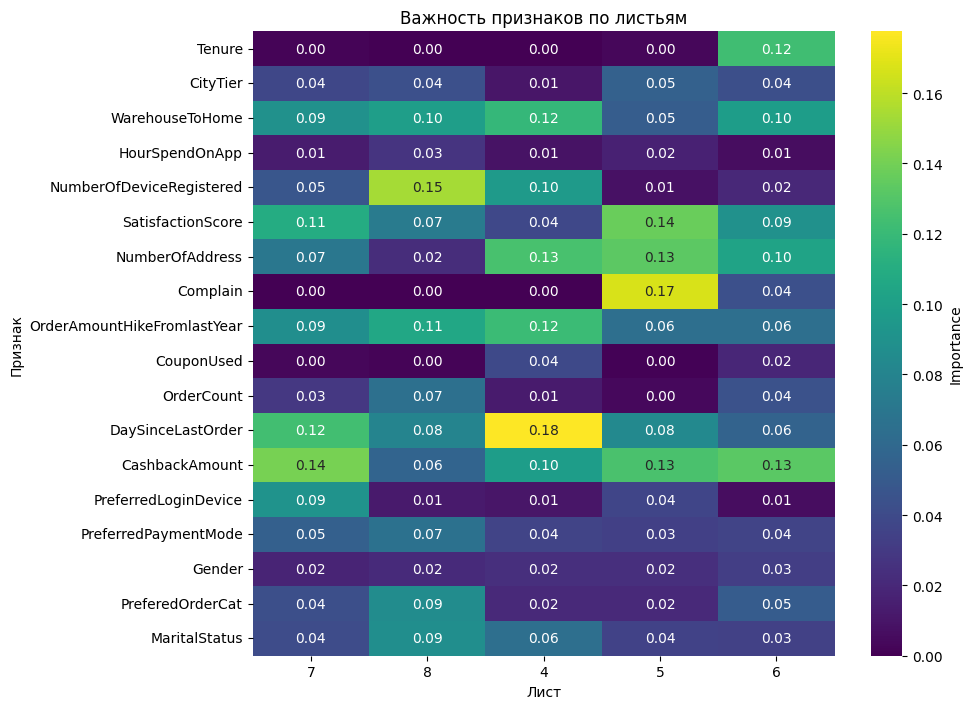

In [ ]:
df_imp = pd.DataFrame(leaf_imps).fillna(0)

plt.figure(figsize=(10, max(4, len(df_imp) * 0.4)))
sns.heatmap(df_imp, cmap='viridis', annot=True, fmt='.2f', cbar_kws={'label': 'Importance'})
plt.title('Важность признаков по листьям')
plt.xlabel('Лист')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()